<a href="https://colab.research.google.com/github/sahilshah9111/KarmixTech_RecommendationSystem/blob/main/Recommendation_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.7 MB/s eta 0:00:00


###1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

import warnings
warnings.filterwarnings("ignore")

###2. Load Dataset

In [3]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


###3. Data Cleaning

**Missing Values**

In [7]:
movies.isnull().sum()

,0
movieId,0
title,0
genres,0


In [8]:
ratings.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [9]:
tags.isnull().sum()

,0
userId,0
movieId,0
tag,0
timestamp,0


In [10]:
print(movies.info())
print(ratings.info())
print(tags.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    36

**Checking Duplicates**

In [11]:
print(movies.duplicated().sum())
print(ratings.duplicated().sum())
print(tags.duplicated().sum())

0
0
0


###Step 4: EDA

In [12]:
print(movies.shape)
print(ratings.shape)
print(tags.shape)

(9742, 3)
(100836, 4)
(3683, 4)


**Rating Distribution**

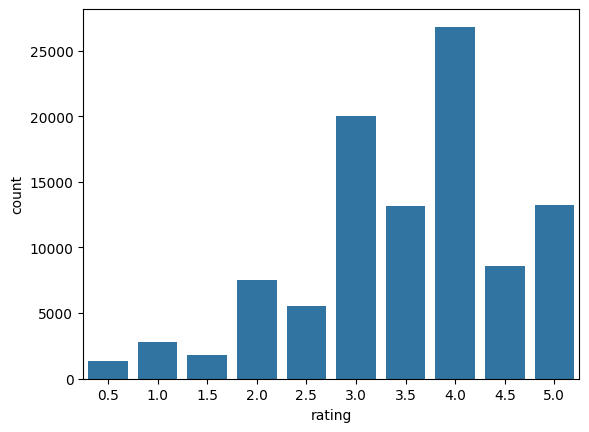

In [13]:
sns.countplot(x='rating', data=ratings)
plt.show()

Inference - Most ratings are between 3 and 5

**Most Active Users**

In [14]:
ratings.groupby('userId')['rating'].count()\
       .sort_values(ascending=False)\
       .head(10)

,rating
userId,
414,2698
599,2478
474,2108
448,1864
274,1346
610,1302
68,1260
380,1218
606,1115


Inference - Small number of users contribute to most ratings.

**Most Rated Movies**

In [15]:
ratings.groupby('movieId')['rating'].count()\
       .sort_values(ascending=False)\
       .head(10)

,rating
movieId,
356,329
318,317
296,307
593,279
2571,278
260,251
480,238
110,237
589,224


Inference - Some movies are more popular than others.

**Sparsity Analysis (important)**

In [16]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

sparsity = (
    1 - num_ratings / (num_users * num_movies)
) * 100

print(f"Sparsity: {sparsity:.2f}%")

Sparsity: 98.30%


The user-item interaction matrix is highly sparse (98.3%), meaning users have rated only a small fraction of available movies. This sparsity makes recommendation challenging and motivates the use of collaborative filtering and hybrid recommendation techniques to predict unseen user preferences.

###Step 5: Merge Data

In [17]:
movie_tags = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.astype(str)))
movie_tags = pd.DataFrame(movie_tags)

movies = movies.merge(movie_tags,
                      on='movieId',
                      how='left')

movies['tag'] = movies['tag'].fillna('')

In [18]:
movies

,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,pixar pixar fun
1,2,Jumanji (1995),Adventure|Children|Fantasy,fantasy magic board game Robin Williams game
2,3,Grumpier Old Men (1995),Comedy|Romance,moldy old
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake
...,...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,
9739,193585,Flint (2017),Drama,
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,


###Step 6: Feature Engineering

**Combine genres and tags**

In [19]:
movies['content'] = (
    movies['genres'].str.replace('|',' ')
    + ' '
    + movies['tag']
)

movies

,movieId,title,genres,tag,content
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,pixar pixar fun,Adventure Animation Children Comedy Fantasy pi...
1,2,Jumanji (1995),Adventure|Children|Fantasy,fantasy magic board game Robin Williams game,Adventure Children Fantasy fantasy magic board...
2,3,Grumpier Old Men (1995),Comedy|Romance,moldy old,Comedy Romance moldy old
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake,Comedy pregnancy remake
...,...,...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,,Action Animation Comedy Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,,Animation Comedy Fantasy
9739,193585,Flint (2017),Drama,,Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,,Action Animation


###Step 7: Content-Based Filtering

**TF-IDF**

In [20]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(movies['content'])

**Cosine Similarity**

In [21]:
similarity = cosine_similarity(tfidf_matrix, tfidf_matrix)

**Create Title Index Mapping**

In [22]:
movie_indices = pd.Series(
    movies.index,
    index=movies['title']
).drop_duplicates()

In [23]:
movie_indices['Toy Story (1995)']

np.int64(0)

**Recommendation Function**

In [24]:
def content_recommend(movie_title, top_n=10):
  if movie_title not in movie_indices.index:
    return ["Movie not found"]

  idx = movie_indices[movie_title]
  scores = list(enumerate(similarity[idx]))
  scores = sorted(scores, key=lambda x: x[1], reverse=True)
  scores = scores[1:top_n+1]
  movie_indices_list = [
        i[0]
        for i in scores
    ]

  recommendations = movies.iloc[
        movie_indices_list
    ][['title']]
  return recommendations['title'].tolist()

**Test Usage**

In [25]:
content_recommend("Toy Story (1995)")

["Bug's Life, A (1998)",
 'Antz (1998)',
 'Adventures of Rocky and Bullwinkle, The (2000)',
 "Emperor's New Groove, The (2000)",
 'Monsters, Inc. (2001)',
 'Wild, The (2006)',
 'Shrek the Third (2007)',
 'Tale of Despereaux, The (2008)',
 'Asterix and the Vikings (Astérix et les Vikings) (2006)',
 'Turbo (2013)']

###Step 8: Collaborative Filtering

**Prepare Dataset**

In [26]:
reader = Reader(rating_scale=(0.5,5))

data = Dataset.load_from_df(
    ratings[['userId',
             'movieId',
             'rating']],
    reader
)

**Train Test Split**

In [27]:
trainset,testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

**Train SVD**

In [28]:
svd = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)
svd.fit(trainset)

**Evaluate**

In [29]:
from surprise import accuracy
predictions = svd.test(testset)
accuracy.rmse(predictions, verbose=True)

RMSE: 0.8807


np.float64(0.8807462819979623)

**Predict Single Rating**

In [30]:
svd.predict(
    uid=1,
    iid=296
)

Prediction(uid=1, iid=296, r_ui=None, est=np.float64(4.364248686466672), details={'was_impossible': False})

**Get Movie Name**

In [31]:
movie_id_to_title = dict(
    zip(
        movies['movieId'],
        movies['title']
    )
)

In [32]:
movie_id_to_title[1]

'Toy Story (1995)'

###Step 9: Collaborative Recommendation

In [33]:
def collaborative_recommend(user_id, top_n=10):
  watched_movies = ratings[ratings['userId']==user_id]['movieId'].tolist()
  movies_not_watched = movies[
        ~movies['movieId'].isin(
            watched_movies
        )
    ]['movieId'].tolist()

  predictions = []
  for movie_id in movies_not_watched:
    pred = svd.predict(
        user_id,
        movie_id
        )

    predictions.append(
        (movie_id,pred.est)
        )

  predictions = sorted(
      predictions,
      key=lambda x:x[1],
      reverse=True
  )

  top_predictions = predictions[:top_n]
  recommended = []

  for movie_id,score in top_predictions:
    title = movie_id_to_title[
            movie_id
        ]

    recommended.append(
        {
            'Movie': title,
            'Predicted Rating':
                round(score,2)
        }
    )

  return pd.DataFrame(recommended)


In [34]:
#Test Usage
collaborative_recommend(
    user_id=1,
    top_n=10
)

,Movie,Predicted Rating
0,Blade Runner (1982),5
1,Ghost in the Shell (Kôkaku kidôtai) (1995),5
2,Dr. Strangelove or: How I Learned to Stop Worr...,5
3,North by Northwest (1959),5
4,Casablanca (1942),5
5,"Streetcar Named Desire, A (1951)",5
6,Cinema Paradiso (Nuovo cinema Paradiso) (1989),5
7,One Flew Over the Cuckoo's Nest (1975),5
8,Lawrence of Arabia (1962),5
9,"Grand Day Out with Wallace and Gromit, A (1989)",5


###Step 10 :Hyperparamater Tuning

In [35]:
from surprise.model_selection import GridSearchCV

**Paramater Grid**

In [36]:
param_grid = {
    'n_factors': [50,100],
    'n_epochs': [20,30],
    'lr_all': [0.002,0.005],
    'reg_all': [0.02,0.1]
}

**Run search:**

In [37]:
gs = GridSearchCV(
    SVD,
    param_grid,
    measures=['rmse'],
    cv=3,
    n_jobs=-1
)

gs.fit(data)

In [38]:
#Best Score
print(gs.best_score['rmse'])

0.8710685660353947


In [39]:
#Best Parameters
print(gs.best_params['rmse'])

{'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.1}


###Step 11: Retrain Model

In [40]:
best_params = gs.best_params['rmse']

In [41]:
best_svd = SVD(
    n_factors=best_params['n_factors'],
    n_epochs=best_params['n_epochs'],
    lr_all=best_params['lr_all'],
    reg_all=best_params['reg_all'],
    random_state=42
)

In [42]:
full_trainset = data.build_full_trainset()

best_svd.fit(
    full_trainset
)

###Step 12: Cold Start Helper

New users have no ratings

In [43]:
# Create popularity recommendations
movie_stats = ratings.groupby(
    'movieId'
).agg({
    'rating':['mean','count']
})

movie_stats.columns = [
    'avg_rating',
    'rating_count'
]

movie_stats.reset_index(
    inplace=True
)

In [44]:
# Merge Titles
movie_stats = movie_stats.merge(
    movies[['movieId','title']],
    on='movieId'
)

In [45]:
# Popular movies:
popular_movies = movie_stats[
    movie_stats['rating_count'] >= 50
].sort_values(
    'avg_rating',
    ascending=False
).head(10)

In [46]:
def cold_start_recommend(top_n=10):
  return popular_movies[['title', 'avg_rating']].head(top_n)

###Step 13: Weighted Hybrid Recommendation

In [47]:
# Create Movie ID Mapping
movieid_to_index = pd.Series(
    movies.index,
    index=movies['movieId']
)

In [48]:
#Improved Content Recommendation
def content_recommend_scores(movie_title, top_n=50):
  idx = movie_indices[movie_title]
  scores = list(enumerate(similarity[idx]))
  scores = sorted(scores, key=lambda x: x[1], reverse=True)
  scores = scores[1:top_n+1]
  recommendations = []
  for movie_idx, score in scores:
    recommendations.append(
        {
            'movieId':
                movies.iloc[movie_idx]['movieId'],
            'title':
                movies.iloc[movie_idx]['title'],
            'content_score':
            score
        }
    )
  return pd.DataFrame(recommendations)

In [49]:
content_df = content_recommend_scores(
    'Toy Story (1995)',
    top_n=100
)

print(content_df.shape)
content_df.head()

(100, 3)


,movieId,title,content_score
0,2355,"Bug's Life, A (1998)",0.550220
1,2294,Antz (1998),0.420284
2,3754,"Adventures of Rocky and Bullwinkle, The (2000)",0.420284
3,4016,"Emperor's New Groove, The (2000)",0.420284
4,4886,"Monsters, Inc. (2001)",0.420284


In [50]:
watched_movies = ratings[
    ratings['userId'] == 1
]['movieId'].tolist()

content_df = content_df[
    ~content_df['movieId'].isin(watched_movies)
]

print(content_df.shape)

(98, 3)


In [51]:
# Hybrid Recommendation Function
def hybrid_recommend(user_id, movie_title, top_n=10):
  #-------------------
  #Cold Start Check
  #-------------------
  if user_id not in ratings['userId'].unique():
    print("New User Detected - Using Cold Start Recommendations")
    return cold_start_recommend(top_n)

  #-------------------
  #Content Candidates
  #-------------------

  content_df = content_recommend_scores(movie_title, top_n=100)

  watched_movies = ratings[
    ratings['userId']==user_id
    ]['movieId'].tolist()

  content_df = content_df[
    ~content_df['movieId'].isin(
        watched_movies
    )]

  hybrid_scores = []
  for _, row in content_df.iterrows():
    movie_id = row['movieId']
    content_score = row['content_score']
    collab_score = svd.predict(user_id, movie_id).est
    hybrid_score = (
        0.4 * content_score
        +
        0.6 * (collab_score / 5)
    )

    hybrid_scores.append({
        'movieId':
        movie_id,

        'title':
        row['title'],

        'content_score':
        round(content_score, 4),

        'collaborative_score':
        round(collab_score, 4),

        'hybrid_score':
        round(hybrid_score, 4)
        })


  results = pd.DataFrame(hybrid_scores)
  results = results.sort_values(
        'hybrid_score',
        ascending=False
    )

  return results.head(top_n)



In [52]:
#Test Hybrid model
hybrid_recommend(
    user_id=1,
    movie_title='Toy Story (1995)',
    top_n=10
)

,movieId,title,content_score,collaborative_score,hybrid_score
0,2355,"Bug's Life, A (1998)",0.5502,4.2813,0.7338
12,3114,Toy Story 2 (1999),0.3962,4.6887,0.7211
4,4886,"Monsters, Inc. (2001)",0.4203,4.6037,0.7206
52,78499,Toy Story 3 (2010),0.3392,4.7077,0.7006
61,72226,Fantastic Mr. Fox (2009),0.3203,4.7635,0.6997
9,103755,Turbo (2013),0.4203,4.3943,0.6954
3,4016,"Emperor's New Groove, The (2000)",0.4203,4.3765,0.6933
11,166461,Moana (2016),0.4203,4.3685,0.6923
17,72356,Partly Cloudy (2009),0.3691,4.4764,0.6848
40,124404,"Snowflake, the White Gorilla (2011)",0.3625,4.4915,0.6840


###Step 14: Evaluation

**Precision@K and Recall@K**

In [53]:
from collections import defaultdict

def precision_recall_at_k(predictions, k=10, threshold=4.0):
  user_est_true = defaultdict(list)
  for uid, _, true_r, est, _ in predictions:
    user_est_true[uid].append((est, true_r))

  precisions = dict()
  recalls = dict()
  for uid, user_ratings in user_est_true.items():
    user_ratings.sort(
            key=lambda x:x[0],
            reverse=True
        )

    n_rel = sum(
            (true_r >= threshold)
            for (_, true_r)
            in user_ratings
        )

    n_rec_k = sum(
            (est >= threshold)
            for (est, _)
            in user_ratings[:k]
        )

    n_rel_and_rec_k = sum(
            (
                (true_r >= threshold)
                and
                (est >= threshold)
            )
            for (est, true_r)
            in user_ratings[:k]
        )

    precisions[uid] = (
            n_rel_and_rec_k / n_rec_k
            if n_rec_k != 0
            else 0
        )

    recalls[uid] = (
            n_rel_and_rec_k / n_rel
            if n_rel != 0
            else 0
        )

  return precisions, recalls

In [54]:
#Compute Precision and Recall
predictions = svd.test(testset)

precisions, recalls = precision_recall_at_k(
    predictions,
    k=10,
    threshold=4
)

In [55]:
#Average Precision@10
precision_at_10 = sum(
    precisions.values()
) / len(
    precisions
)

print(
    "Precision@10:",
    round(
        precision_at_10,
        4
    )
)

Precision@10: 0.566


In [56]:
#Average Recall@10
recall_at_10 = sum(
    recalls.values()
) / len(
    recalls
)

print(
    "Recall@10:",
    round(
        recall_at_10,
        4
    )
)

Recall@10: 0.2794


In [57]:
#Evaluation Summary Table
evaluation_results = pd.DataFrame({

    'Metric': [
        'RMSE',
        'Precision@10',
        'Recall@10'
    ],

    'Value': [

        round(
            accuracy.rmse(
                predictions,
                verbose=False
            ),
            4
        ),

        round(
            precision_at_10,
            4
        ),

        round(
            recall_at_10,
            4
        )
    ]
})

evaluation_results

,Metric,Value
0,RMSE,0.8807
1,Precision@10,0.5660
2,Recall@10,0.2794


The collaborative filtering model based on SVD achieved an RMSE of 0.88 on the test set, indicating good rating prediction accuracy. The recommender attained a Precision@10 of 0.566, meaning over half of the top-10 recommendations were relevant to users. Recall@10 was 0.279, showing the model successfully retrieved a meaningful subset of relevant movies while maintaining recommendation quality.

###Step 15: Saving Models

In [ ]:
#Create Artifacts Folder
import os
os.makedirs('artifacts', exist_ok=True)

In [ ]:
import pickle

with open('artifacts/svd_model.pkl', 'wb') as f:
  pickle.dump(svd, f)

with open('artifacts/tfidf.pkl', 'wb') as f:
  pickle.dump(tfidf, f)

with open('artifacts/similarity.pkl', 'wb') as f:
  pickle.dump(similarity, f)

with open('artifacts/movie_indices.pkl', 'wb') as f:
  pickle.dump(movie_indices, f)

with open('artifacts/movie_id_to_title.pkl', 'wb') as f:
  pickle.dump(movie_id_to_title, f)

movies.to_csv('artifacts/movies_processed.csv', index=False)

ratings.to_csv('artifacts/ratings_processed.csv', index=False)

In [ ]:
os.listdir('artifacts')

['similarity.pkl',
 'tfidf.pkl',
 'movies_processed.csv',
 'svd_model.pkl',
 'ratings_processed.csv',
 'movie_id_to_title.pkl',
 'movie_indices.pkl']

In [ ]:
!zip -r recommender_artifacts.zip artifacts

  adding: artifacts/ (stored 0%)
  adding: artifacts/similarity.pkl (deflated 79%)
  adding: artifacts/tfidf.pkl (deflated 77%)
  adding: artifacts/movies_processed.csv (deflated 71%)
  adding: artifacts/svd_model.pkl (deflated 21%)
  adding: artifacts/ratings_processed.csv (deflated 71%)
  adding: artifacts/movie_id_to_title.pkl (deflated 53%)
  adding: artifacts/movie_indices.pkl (deflated 63%)


In [ ]:
from google.colab import files

files.download('recommender_artifacts.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Step 16: Business Insights

**1. User Preferences Drive Engagement**

**Observation**:

Different users receive different recommendations.

Example:

User 1 gets highly-rated animation and family movies.
User 10 gets critically acclaimed dramas and classics.
User 50 gets a different set altogether.

**Business Insight**:

Users have diverse tastes, so personalized recommendations are more effective than showing the same trending movies to everyone.

**Business Recommendation**:

Replace generic homepages with personalized recommendation sections to increase watch time and user engagement.

**2. Hybrid Models Improve Recommendation Quality**

**Insight**:

Content-based recommendations alone may be too similar.

Collaborative filtering alone may ignore the user's current interest.

The hybrid model balances both.

**Recommendation**:

Use hybrid recommendation systems in production because they combine user behavior with movie similarity, improving relevance and diversity.

**3. Popular Movies Are Not Always the Best Recommendation**

Cold-start recommendations rely on popular/highly-rated movies.

Examples often include:

*   The Shawshank Redemption
*   The Godfather
*   Pulp Fiction

**Insight**:

Popular movies help new users but become less effective once user history is available.

**Recommendation**:

Use popularity-based recommendations only for new users, then transition to personalized recommendations after sufficient interaction data is collected.

**4. User Behavior Signals Are Valuable**

Your collaborative filtering model learned from:

'User Ratings'

**Insight**:

The more interactions a user provides, the better the recommendations become.

**Recommendation**:

Encourage users to rate movies, like content, or maintain watchlists to improve personalization quality.

**5. Recommendation Quality Is Reasonable**

**Your evaluation**:

Metric	     Result

RMSE	         0.8807

Precision@10	0.566

Recall@10	     0.2794

**Insight**:

More than half of the Top-10 recommendations are relevant.

**Recommendation**:

Deploy the recommender and monitor online engagement metrics such as CTR (Click Through Rate), watch time, and retention to further optimize recommendation performance.